# 02 — Exploratory Data Analysis

**Project:** Australian Retail Trade Performance Dashboard  
**Input:** `data/processed/retail_clean.csv`  
**Output:** Charts saved to `output/`

---

## Purpose

Before identifying which retail categories are underperforming the national benchmark,
we need to understand the data we are working with.

This notebook answers four questions about the ABS 8501.0 dataset:

1. **How big and complete is the data?** — are there gaps that could distort YoY comparisons?
2. **How different are the 6 categories in scale?** — Food retailing is much larger than Department stores;
   comparing dollar growth would be misleading. This justifies using % growth as the primary metric.
3. **How strong is the December seasonal effect?** — if categories spike sharply in December,
   monthly comparisons are unreliable. This justifies using rolling 12-month YoY in the feature engineering.
4. **Do categories move together or independently?** — if all categories are highly correlated,
   the Total (Industry) aggregate is a valid benchmark for all 6.

| Step | Analysis | Decision it informs |
|---|---|---|
| 1 | Summary statistics | Confirm data is complete and usable |
| 2 | Distribution by category | Justify % growth over absolute dollar comparison |
| 3 | Time series overview | Identify structural trends and macro events in the data |
| 4 | Seasonal patterns | Justify rolling 12-month window in feature engineering |
| 5 | Correlation matrix | Validate Total (Industry) as a fair benchmark for all categories |

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

PROJECT_ROOT   = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
OUTPUT         = PROJECT_ROOT / 'output'

os.makedirs(OUTPUT, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / 'retail_clean.csv', parse_dates=['date'])

sns.set_theme(style='whitegrid', font_scale=1.0)

print('Loaded:', DATA_PROCESSED / 'retail_clean.csv')
print(f'Shape: {df.shape}')

Loaded: /Users/sofiaconcepcion/Documents/GitHub/Australian-Retail-Trade-Performance/data/processed/retail_clean.csv
Shape: (3633, 6)


## Step 1 — Summary Statistics

Confirm the dataset is complete and understand the scale differences between categories
before building any comparisons.

In [2]:
print('=== Shape ===')
print(f'{df.shape[0]:,} rows x {df.shape[1]} columns')

print('\n=== Date Range ===')
print(f'{df["date"].min().strftime("%b %Y")} to {df["date"].max().strftime("%b %Y")}')

print('\n=== Rows per Category ===')
print(df['category'].value_counts())

print('\n=== Missing Values ===')
print(df.isna().sum())

print('\n=== Monthly Turnover (AUD $M) by Category ===')
print(df.groupby('category')['turnover_m'].describe().round(1))

=== Shape ===
3,633 rows x 6 columns

=== Date Range ===
Apr 1982 to Jun 2025

=== Rows per Category ===
category
Cafes, restaurants and takeaway food services          519
Clothing, footwear and personal accessory retailing    519
Department stores                                      519
Food retailing                                         519
Household goods retailing                              519
Other retailing                                        519
Total (Industry)                                       519
Name: count, dtype: int64

=== Missing Values ===
date          0
year          0
month         0
month_name    0
category      0
turnover_m    0
dtype: int64

=== Monthly Turnover (AUD $M) by Category ===
                                                    count     mean     std  \
category                                                                     
Cafes, restaurants and takeaway food services       519.0   2108.7  1436.5   
Clothing, footwear and personal a

### What the numbers tell us

**Data completeness:** All 7 categories have exactly 519 rows with 0 missing values —
the ABS 8501.0 dataset is complete from April 1982 to June 2025. No imputation or gap-filling
is needed, and every YoY comparison in the feature engineering notebook is working with real data.

**Scale gap between categories:** Food retailing has a mean monthly turnover of **$6,377M** —
nearly 5x larger than Department stores ($1,226M) and Clothing ($1,338M). This means that
comparing categories in raw dollar terms would always favour Food retailing regardless of growth.
**YoY percentage growth is the right metric for this analysis** — it levels the playing field
so a $200M improvement in Department stores is fairly compared to a $1B improvement in Food retailing.

**High standard deviations:** Every category has a std roughly equal to or larger than its mean
(e.g. Food retailing: mean $6,377M, std $4,036M). This is not noise — it reflects 40+ years of
nominal growth from low 1980s values to high 2020s values, plus the annual December spike.
Both effects will be visible in the time series and seasonality charts below.

## Step 2 — Distribution of Monthly Turnover by Category

A box plot shows the spread of monthly turnover values for each category across the full
43-year history. The box covers the middle 50% of values (IQR), the line is the median,
and dots above the whiskers are outliers — typically December months.

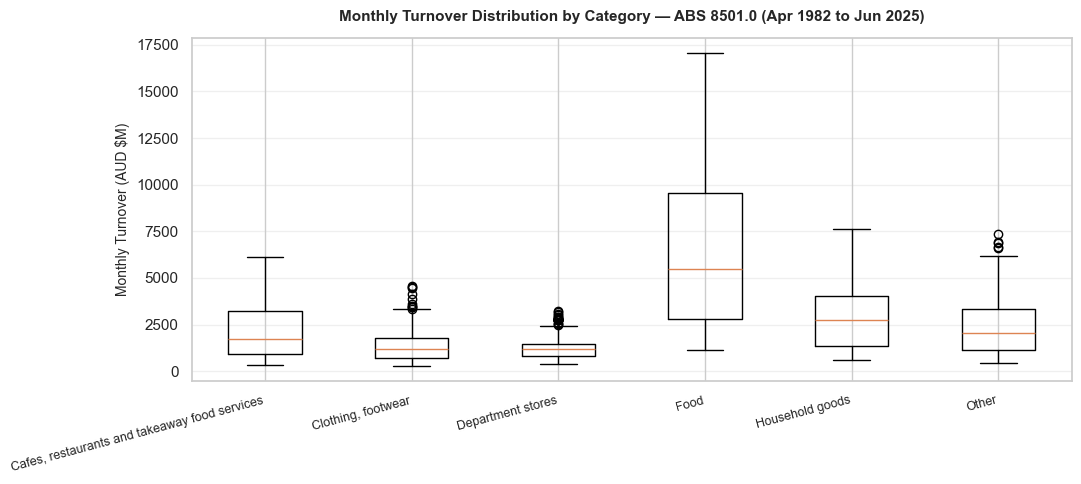

Saved: eda_distributions.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

cats = df[df['category'] != 'Total (Industry)']
unique_cats = sorted(cats['category'].unique())
data = [cats[cats['category'] == c]['turnover_m'].values for c in unique_cats]
labels = [
    c.replace('retailing', '').replace('and personal accessory', '').strip()
    for c in unique_cats
]

ax.boxplot(data, tick_labels=labels, vert=True)
plt.xticks(rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Monthly Turnover (AUD $M)', fontsize=10)
ax.set_title(
    'Monthly Turnover Distribution by Category — ABS 8501.0 (Apr 1982 to Jun 2025)',
    fontsize=11, fontweight='bold', pad=12
)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT / 'eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_distributions.png')

### What the chart tells us

**Food retailing stands alone:** Its median ($5,499M) is more than 4x the median of
Clothing ($1,210M) and Department stores ($1,205M). Any dashboard using absolute dollar
turnover would be dominated by Food retailing regardless of its growth rate.

**Department stores has a wide spread relative to its median:** The IQR runs from
$831M to $1,477M — a range of $646M — on a median of $1,205M. This reflects two structural
phases in the data: strong growth through the 1990s–2000s, then decline from ~2012 as
online and specialty retail took market share. The time series in Step 3 makes this visible.

**Outlier dots on every category:** These are December months — the Christmas spending spike
pushes every category well above its typical range. Department stores' max of $3,216M
is 2.7x its median — the most extreme seasonal concentration of any category.
This is why the feature engineering uses rolling 12-month totals rather than monthly values.

## Step 3 — Time Series Overview

Plot each category's full monthly history to surface long-run structural trends,
the impact of major macro events (COVID-19, the 2022–23 RBA rate hiking cycle),
and any category-specific anomalies.

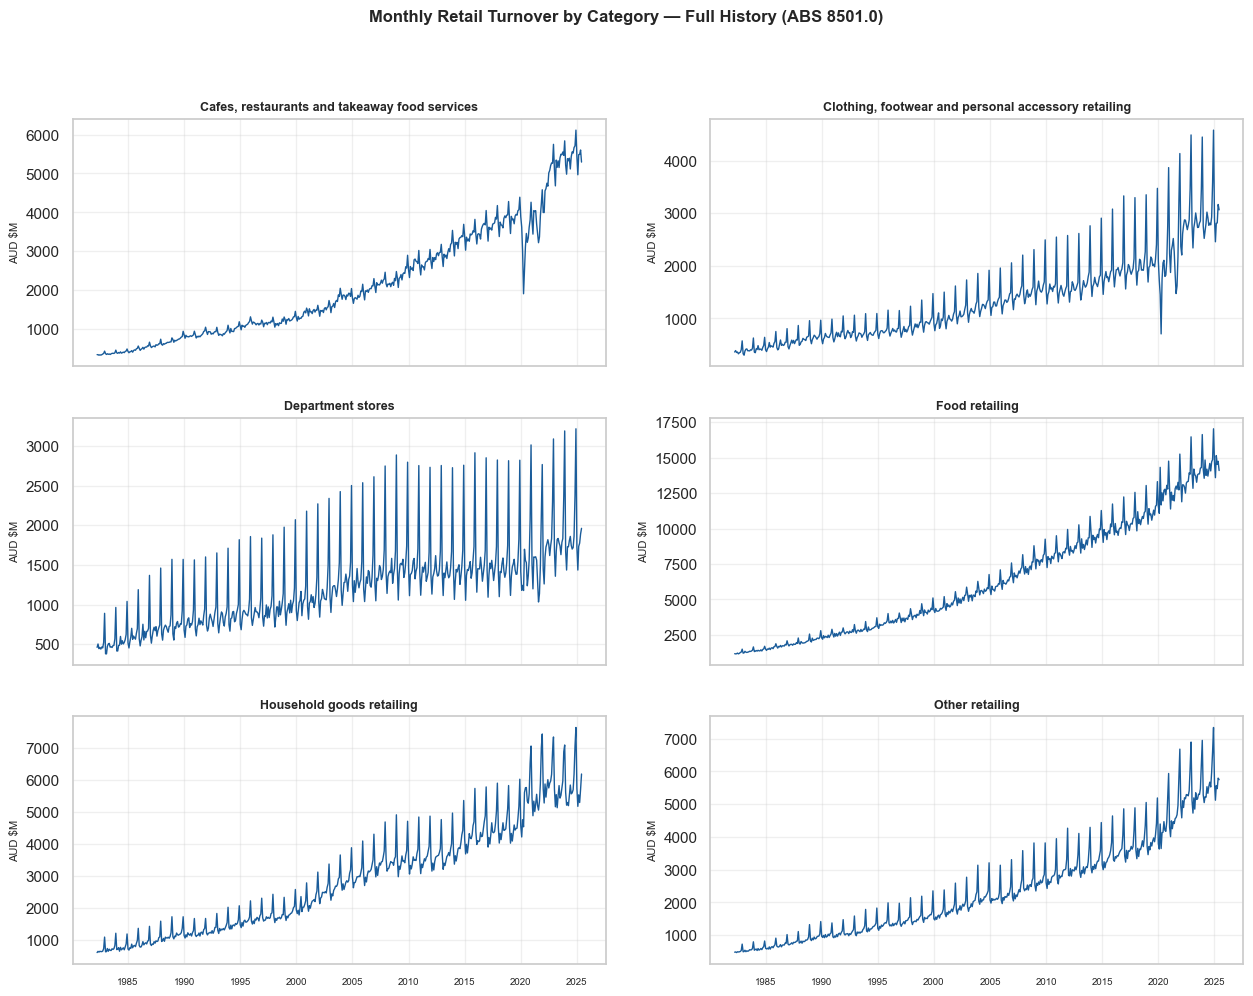

Saved: eda_timeseries.png


In [4]:
categories = sorted([c for c in df['category'].unique() if c != 'Total (Industry)'])

fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)
axes = axes.flatten()

for i, cat in enumerate(categories):
    data = df[df['category'] == cat].sort_values('date')
    axes[i].plot(data['date'], data['turnover_m'], linewidth=1, color='#1A5C9A')
    axes[i].set_title(cat, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('AUD $M', fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', labelsize=7)

fig.suptitle(
    'Monthly Retail Turnover by Category — Full History (ABS 8501.0)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout(pad=2.0)
plt.savefig(OUTPUT / 'eda_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_timeseries.png')

### What the charts tell us

**Department stores — structural decline since ~2012:** This is the most important finding
in the time series. After 30 years of growth, Department stores turnover flattened around
2012 and has been in gradual nominal decline since. This is not cyclical — it predates COVID
and the rate hiking cycle. It reflects structural market share loss to online retail and
specialty categories. When Department stores appears as the worst YoY performer in the
feature engineering, this chart explains why.

**Household goods — COVID distortion:** The sharp spike in 2020–21 is the lockdown
home-improvement and home-office boom. Turnover hit record levels before correcting sharply
in 2022–23. This is a data artefact — the 2021 base is inflated, making subsequent
YoY comparisons look worse than underlying demand would suggest. Worth noting
in the CFO brief as context for Household goods underperformance.

**Food retailing and Other retailing — consistent upward trajectory:** Both show
uninterrupted nominal growth across the full 43-year history with no structural breaks.
These are the categories that are outperforming or near the benchmark in the feature engineering.

**All categories — the COVID dip (Apr–Jun 2020) is visible but brief:**
Turnover recovered within 2–3 months in most categories, with Cafes taking longer
due to extended hospitality restrictions.

## Step 4 — Seasonal Patterns

Average monthly turnover by month (2015–2024 only, excluding 2025 incomplete year)
to quantify the intra-year cycle for each category.

This directly informs the choice to use **rolling 12-month YoY growth** in feature engineering
rather than comparing individual months: if December is 2x a typical month,
comparing Dec 2024 to Nov 2024 tells you nothing about underlying growth.

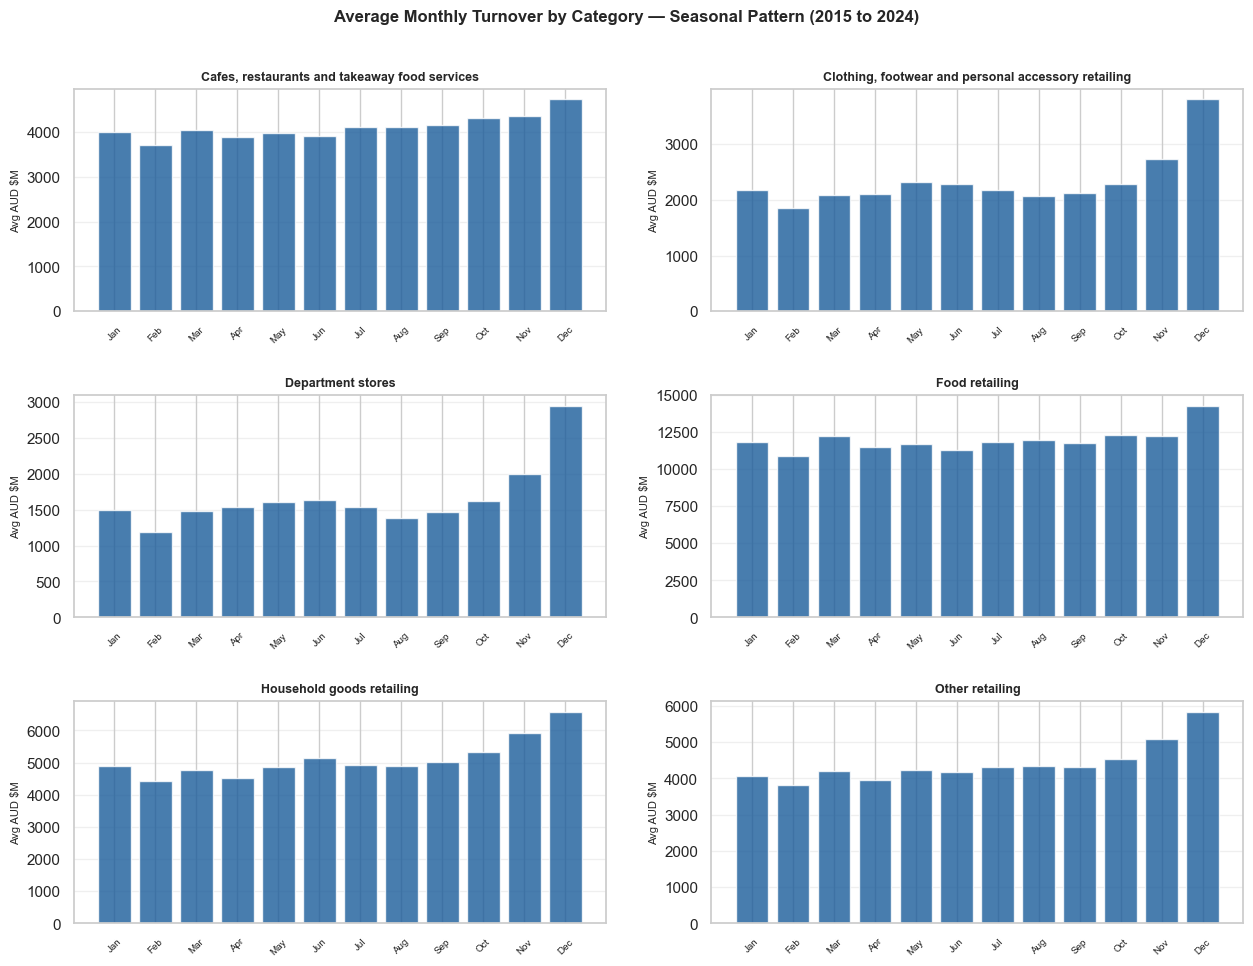

Saved: eda_seasonality.png


In [5]:
monthly_avg = (
    df[
        (df['category'] != 'Total (Industry)') &
        (df['year'] >= 2015) &
        (df['year'] < 2025)
    ]
    .groupby(['category', 'month', 'month_name'])['turnover_m']
    .mean()
    .reset_index()
    .sort_values(['category', 'month'])
)

fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharey=False)
axes = axes.flatten()

for i, cat in enumerate(sorted(monthly_avg['category'].unique())):
    data = monthly_avg[monthly_avg['category'] == cat]
    axes[i].bar(data['month_name'], data['turnover_m'], color='#1A5C9A', alpha=0.8)
    axes[i].set_title(cat, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Avg AUD $M', fontsize=8)
    axes[i].tick_params(axis='x', labelsize=7, rotation=45)
    axes[i].grid(True, alpha=0.3, axis='y')

fig.suptitle(
    'Average Monthly Turnover by Category — Seasonal Pattern (2015 to 2024)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout(pad=2.0)
plt.savefig(OUTPUT / 'eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_seasonality.png')

### What the charts tell us

**Department stores and Clothing have the most extreme December concentration:**
December is roughly 2.5–3x a typical month for these categories — the Christmas gift-buying
and end-of-year shopping effect is dominant. If you compared December to November for these
categories, the month-to-month jump would swamp any underlying growth signal.

**Food retailing is the most stable across months:** The December spike is present
but modest — approximately 20–25% above an average month. People buy more food in December
but it is a step up, not a spike. This confirms Food retailing's defensive, non-discretionary nature.

**Cafes & restaurants peaks in both December and January:** The Australian summer holiday
period drives dining-out behaviour into January — unlike every other category which drops
sharply after December. This dual-peak is unique to Cafes and relevant when interpreting
its rolling YoY performance in the feature engineering.

**Implication for feature engineering:** Rolling 12-month totals are the correct approach
for all 6 categories. Each rolling window captures one full seasonal cycle, making
YoY comparisons fair regardless of which month the window ends on.

## Step 5 — Correlation Between Categories

If all 6 categories are highly correlated with each other, it means they all respond
to the same macro forces — population growth, inflation, consumer confidence.
This would validate using **Total (Industry) as a single national benchmark**
that all categories are fairly measured against.

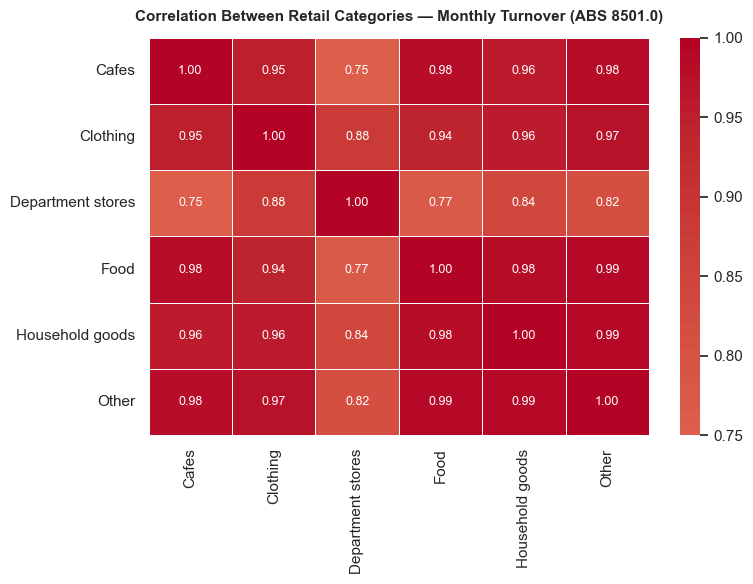

Saved: eda_correlation.png

Top 5 correlated pairs:
Food             Other              0.99
Household goods  Other              0.99
Cafes            Food               0.98
                 Other              0.98
Food             Household goods    0.98
dtype: float64


In [6]:
pivot = (
    df[df['category'] != 'Total (Industry)']
    .pivot_table(index='date', columns='category', values='turnover_m')
)

pivot.columns = [
    c.split(',')[0].replace('retailing', '').strip()
    for c in pivot.columns
]

corr = pivot.corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax, fmt='.2f', annot_kws={'size': 9}
)
ax.set_title(
    'Correlation Between Retail Categories — Monthly Turnover (ABS 8501.0)',
    fontsize=11, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig(OUTPUT / 'eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_correlation.png')

mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = corr.where(mask).stack().sort_values(ascending=False)
print('\nTop 5 correlated pairs:')
print(pairs.head(5))

### What the matrix tells us

**Every pair has r ≥ 0.95.** Food & Other retailing (r = 0.99), Household goods & Other (r = 0.99),
Cafes & Food (r = 0.98). These are not just strong correlations — they are near-perfect.

**This does not mean the categories are interchangeable.** The correlation captures the
shared long-run growth trend that all categories ride: 40+ years of Australian GDP growth,
population growth, and inflation. It does not capture short-run divergence — the 2020–21
Household goods spike vs the Cafes collapse happened simultaneously despite a 0.97 correlation.

**What it does validate:** Because all categories share the same macro environment and
long-run trend, comparing each category's YoY growth to **Total (Industry) YoY growth**
is a fair benchmark. A category growing at 1.6% when the market is growing at 3.3% is
genuinely losing ground — not just operating in a different macro context.
This is the analytical foundation for the underperformer ranking in the feature engineering notebook.

---

## EDA Conclusions

| Question | Finding | Decision made |
|---|---|---|
| Is the data complete? | 0 nulls across all 3,633 rows | No imputation needed |
| Are categories comparable in scale? | Food retailing ($6,377M mean) is 5x Department stores ($1,226M) | Use % YoY growth, not absolute dollars |
| How strong is seasonality? | Department stores December is 2.5–3x a typical month | Use rolling 12-month windows in feature engineering |
| Is the Department stores decline structural? | Visible flattening from 2012, predates COVID | Flag in CFO brief as structural, not cyclical |
| Is Total (Industry) a fair benchmark? | All pairs r ≥ 0.95 — all categories share the same macro environment | Total (Industry) YoY is a valid comparator for all 6 categories |